# Bayesian Black-Box Optimisation — Round 6
**Imperial Business School | Executive Master ML/AI — BBO Capstone**  
**Author:** Gian Franco Cattaneo  
**Module:** W17 | 15 data points per function (5 rounds completed)  
**Objective:** Maximisation over [0, 0.999999]ⁿ  
**Kernel:** Matérn-5/2 ARD + WhiteKernel | Acquisition: Expected Improvement (maximisation)

---

## Notebook Structure
1. Dependencies & global configuration  
2. Full historical dataset (Rounds 1–5)  
3. GP surrogate infrastructure (build / fit / EI-maximise)  
4. Function-by-function analysis with diagnostic plots  
5. Round 6 query proposals — hybrid GP-EI + gradient analysis  
6. Final submission strings  
7. CNN trade-off reflection (Part 2)

---
## Cell 1 — Dependencies

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm
from scipy.optimize import minimize

np.random.seed(42)
SEED = 42

print("Dependencies loaded.")

Dependencies loaded.


In [7]:
from pathlib import Path

# ── Output directory (cross-platform) ─────────────────────────────────────────
OUTPUT_DIR = Path.home() / "BBO_Round6_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Outputs will be saved to: {OUTPUT_DIR}")

Outputs will be saved to: C:\Users\gianfranco.cattaneo\BBO_Round6_outputs


---
## Cell 2 — Full Historical Dataset (Rounds 1–5)

In [8]:
# ─── Round inputs and outputs ─────────────────────────────────────────────────
# Each entry: {"d": int, "X": list[list[float]], "y": list[float]}

DATA = {
    "f1": {
        "d": 2,
        "X": [
            [0.034388, 0.909319],   # R1
            [0.999999, 0.999999],   # R2
            [0.250000, 0.250000],   # R3
            [0.500000, 0.500000],   # R4
            [0.472781, 0.505546],   # R5
        ],
        "y": [
            2.4674747069022486e-270,
            1.517648729565899e-192,
            9.797748409814019e-42,
            2.6752879910742468e-9,
            8.168635327996585e-8,
        ],
    },
    "f2": {
        "d": 2,
        "X": [
            [0.695196, 0.395970],   # R1
            [0.698486, 0.000000],   # R2
            [0.695000, 0.396000],   # R3
            [0.700000, 0.200000],   # R4
            [0.695211, 0.395970],   # R5
        ],
        "y": [
            0.7237404632835625,
            0.5297658866453171,
            0.5263661301012157,
            0.5813540452269076,
            0.6238852457166373,
        ],
    },
    "f3": {
        "d": 3,
        "X": [
            [0.548145, 0.174647, 0.303245],   # R1
            [0.850892, 0.035316, 0.936193],   # R2
            [0.300000, 0.500000, 0.700000],   # R3
            [0.950000, 0.010000, 0.990000],   # R4
            [0.511275, 0.215264, 0.371049],   # R5
        ],
        "y": [
            -0.08911956876452833,
            -0.23982430098711077,
            -0.1139602029925284,
            -0.4594065810473597,
            -0.0707083820875107,
        ],
    },
    "f4": {
        "d": 4,
        "X": [
            [0.440429, 0.425456, 0.378357, 0.397088],   # R1
            [0.999999, 0.000000, 0.000000, 0.365908],   # R2
            [0.440000, 0.425000, 0.378000, 0.397000],   # R3
            [0.999999, 0.000000, 0.000000, 0.700000],   # R4
            [0.455000, 0.415000, 0.385000, 0.395000],   # R5
        ],
        "y": [
            0.25957575200735095,
            -27.859767965401783,
            0.2748080020297299,
            -30.894440825162423,
            -0.3996600230633507,
        ],
    },
    "f5": {
        "d": 4,
        "X": [
            [0.000000, 0.675974, 0.999999, 0.999999],   # R1
            [0.000000, 0.000000, 0.999999, 0.999999],   # R2
            [0.000000, 0.850000, 0.999999, 0.999999],   # R3
            [0.000000, 0.000000, 0.500000, 0.500000],   # R4
            [0.000000, 0.999999, 0.999999, 0.999999],   # R5
        ],
        "y": [
            2105.928152398213,
            1616.625747348229,
            2932.694991178572,
            83.9625,
            4440.480873479282,
        ],
    },
    "f6": {
        "d": 5,
        "X": [
            [0.464677, 0.242110, 0.574863, 0.999999, 0.000000],   # R1
            [0.142734, 0.321812, 0.416483, 0.999999, 0.304415],   # R2
            [0.500000, 0.500000, 0.500000, 0.500000, 0.500000],   # R3
            [0.300000, 0.400000, 0.600000, 0.200000, 0.600000],   # R4
            [0.758817, 0.272673, 0.522143, 0.999999, 0.000000],   # R5
        ],
        "y": [
            -0.5507747202906804,
            -1.0045153236844038,
            -1.0159268487405835,
            -1.223884840915805,
            -0.9105784720492842,
        ],
    },
    "f7": {
        "d": 6,
        "X": [
            [0.000000, 0.241713, 0.327655, 0.218095, 0.375335, 0.747501],   # R1
            [0.000000, 0.302741, 0.000000, 0.187177, 0.000000, 0.167183],   # R2
            [0.000000, 0.242000, 0.328000, 0.218000, 0.375000, 0.748000],   # R3
            [0.000000, 0.150000, 0.000000, 0.100000, 0.000000, 0.100000],   # R4
            [0.000000, 0.260000, 0.340000, 0.232000, 0.395000, 0.752000],   # R5
        ],
        "y": [
            2.207308607344047,
            0.050978228653516464,
            2.2071746109147172,
            0.02363347322274405,
            2.113257173327904,
        ],
    },
    "f8": {
        "d": 8,
        "X": [
            [0.064016, 0.008062, 0.123268, 0.000000, 0.999999, 0.381742, 0.031402, 0.806010],   # R1
            [0.096074, 0.000000, 0.581701, 0.000000, 0.999999, 0.383890, 0.202188, 0.999999],   # R2
            [0.064000, 0.008000, 0.120000, 0.000000, 0.999999, 0.382000, 0.031000, 0.806000],   # R3
            [0.100000, 0.000000, 0.800000, 0.000000, 0.999999, 0.380000, 0.350000, 0.999999],   # R4
            [0.040000, 0.000000, 0.090000, 0.005000, 0.999999, 0.367013, 0.020000, 0.780000],   # R5
        ],
        "y": [
            9.8595486103895,
            9.2933769573024,
            9.8591545999995,
            8.5129002799994,
            9.8387496578305,
        ],
    },
}

print("Dataset loaded: 8 functions, 5 rounds each.")
print(f"{'Fn':<5} {'d':>3}  {'Best y':>14}  {'Worst y':>14}  {'Best input'}")
print("-" * 75)
for fn, info in DATA.items():
    y = np.array(info["y"])
    X = np.array(info["X"])
    idx_best = np.argmax(y)
    best_x_str = "  ".join(f"{v:.4f}" for v in X[idx_best])
    print(f"{fn:<5} {info['d']:>3}  {np.max(y):>14.6g}  {np.min(y):>14.6g}  [{best_x_str}]")

Dataset loaded: 8 functions, 5 rounds each.
Fn      d          Best y         Worst y  Best input
---------------------------------------------------------------------------
f1      2     8.16864e-08    2.46747e-270  [0.4728  0.5055]
f2      2         0.72374        0.526366  [0.6952  0.3960]
f3      3      -0.0707084       -0.459407  [0.5113  0.2153  0.3710]
f4      4        0.274808        -30.8944  [0.4400  0.4250  0.3780  0.3970]
f5      4         4440.48         83.9625  [0.0000  1.0000  1.0000  1.0000]
f6      5       -0.550775        -1.22388  [0.4647  0.2421  0.5749  1.0000  0.0000]
f7      6         2.20731       0.0236335  [0.0000  0.2417  0.3277  0.2181  0.3753  0.7475]
f8      8         9.85955          8.5129  [0.0640  0.0081  0.1233  0.0000  1.0000  0.3817  0.0314  0.8060]


---
## Cell 3 — GP Surrogate Infrastructure

In [9]:
# ─── Core GP functions ────────────────────────────────────────────────────────

def build_gp(X: np.ndarray, y: np.ndarray,
             n_restarts: int = 35) -> tuple:
    """
    Fit a GP surrogate with Matérn-5/2 ARD kernel + WhiteKernel.
    Returns (gp, scaler) — inputs are StandardScaled before fitting.
    """
    d = X.shape[1]
    kernel = (
        1.0 * Matern(
            length_scale=np.ones(d),
            length_scale_bounds=(1e-2, 10.0),
            nu=2.5,
        )
        + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-6, 1e-1))
    )
    gp = GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=n_restarts,
        normalize_y=True,
        random_state=SEED,
    )
    sc = StandardScaler()
    gp.fit(sc.fit_transform(X), y)
    return gp, sc


def ei_maximisation(x_flat: np.ndarray,
                    gp: GaussianProcessRegressor,
                    sc: StandardScaler,
                    y_best: float,
                    xi: float = 0.01) -> float:
    """
    Negative EI for maximisation (scipy.minimize minimises).
    EI = (μ - y_best - ξ) * Φ(Z) + σ * φ(Z)
    where Z = (μ - y_best - ξ) / σ
    """
    x = np.atleast_2d(x_flat)
    mu, sigma = gp.predict(sc.transform(x), return_std=True)
    sigma = np.maximum(sigma, 1e-9)
    z = (mu - y_best - xi) / sigma
    ei = (mu - y_best - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    return -float(ei[0])


def optimise_ei(gp: GaussianProcessRegressor,
                sc: StandardScaler,
                y_best: float,
                d: int,
                n_restarts: int = 200,
                xi: float = 0.01) -> tuple:
    """
    Multi-start L-BFGS-B maximisation of EI over [0, 0.999999]^d.
    Returns (x_best, ei_best).
    """
    bounds = [(0.0, 0.999999)] * d
    best_ei, best_x = -np.inf, None
    rng = np.random.default_rng(SEED)
    for _ in range(n_restarts):
        x0 = rng.uniform(0.0, 0.999999, d)
        res = minimize(
            ei_maximisation, x0,
            args=(gp, sc, y_best, xi),
            method="L-BFGS-B",
            bounds=bounds,
        )
        ei_val = -res.fun
        if ei_val > best_ei:
            best_ei = ei_val
            best_x = res.x
    return best_x, best_ei


print("GP infrastructure ready.")
print("  build_gp()        — Matérn-5/2 ARD + WhiteKernel, StandardScaler")
print("  ei_maximisation() — EI(x) for maximisation objective")
print("  optimise_ei()     — 200-restart L-BFGS-B over [0, 0.999999]^d")

GP infrastructure ready.
  build_gp()        — Matérn-5/2 ARD + WhiteKernel, StandardScaler
  ei_maximisation() — EI(x) for maximisation objective
  optimise_ei()     — 200-restart L-BFGS-B over [0, 0.999999]^d


---
## Cell 4 — Per-Function Analysis and Round 6 Query Derivation

### f1 (d=2) — Sharply peaked Gaussian, log-space GP

In [10]:
# ─── f1: outputs span ~270 orders of magnitude → log10-transform ─────────────
info = DATA["f1"]
X1 = np.array(info["X"])
y1_raw = np.array(info["y"])

# Log10 transform (floor at 1e-310 to avoid -inf)
y1 = np.log10(np.maximum(y1_raw, 1e-310))

print("f1 — log10(y) values:")
for i, (x, yl, yr) in enumerate(zip(X1, y1, y1_raw)):
    print(f"  R{i+1}: x={list(np.round(x,6))} → log10(y)={yl:.2f}  (raw={yr:.4e})")

# Gradient extrapolation: direction R4 → R5
dx_r4_r5 = X1[4] - X1[3]
dlog = y1[4] - y1[3]
x_r6_extrap = np.clip(X1[4] + dx_r4_r5, 0.0, 0.999999)

print(f"\nGradient direction R4→R5 : Δx = {np.round(dx_r4_r5, 6)}")
print(f"Log improvement          : Δlog₁₀ = {dlog:.3f}  (→ {10**dlog:.1f}× output gain)")
print(f"Extrapolated R6 query    : {np.round(x_r6_extrap, 6)}")

# GP in log-space
gp1, sc1 = build_gp(X1, y1)
y_best1 = np.max(y1)
xq1_gp, ei1 = optimise_ei(gp1, sc1, y_best1, d=2, xi=0.5)
print(f"\nGP-EI suggestion (log-space): {np.round(xq1_gp, 6)}  |  EI={ei1:.4g} log-units")

# Strategy: gradient extrapolation is more reliable here
# (GP is poorly conditioned in log-space with only 5 points)
xq1_final = x_r6_extrap
print(f"\n★  f1 ROUND 6 QUERY (gradient extrapolation): {np.round(xq1_final, 6)}")

f1 — log10(y) values:
  R1: x=[0.034388, 0.909319] → log10(y)=-269.61  (raw=2.4675e-270)
  R2: x=[0.999999, 0.999999] → log10(y)=-191.82  (raw=1.5176e-192)
  R3: x=[0.25, 0.25] → log10(y)=-41.01  (raw=9.7977e-42)
  R4: x=[0.5, 0.5] → log10(y)=-8.57  (raw=2.6753e-09)
  R5: x=[0.472781, 0.505546] → log10(y)=-7.09  (raw=8.1686e-08)

Gradient direction R4→R5 : Δx = [-0.027219  0.005546]
Log improvement          : Δlog₁₀ = 1.485  (→ 30.5× output gain)
Extrapolated R6 query    : [0.445562 0.511092]

GP-EI suggestion (log-space): [0.999999 0.567223]  |  EI=10.41 log-units

★  f1 ROUND 6 QUERY (gradient extrapolation): [0.445562 0.511092]


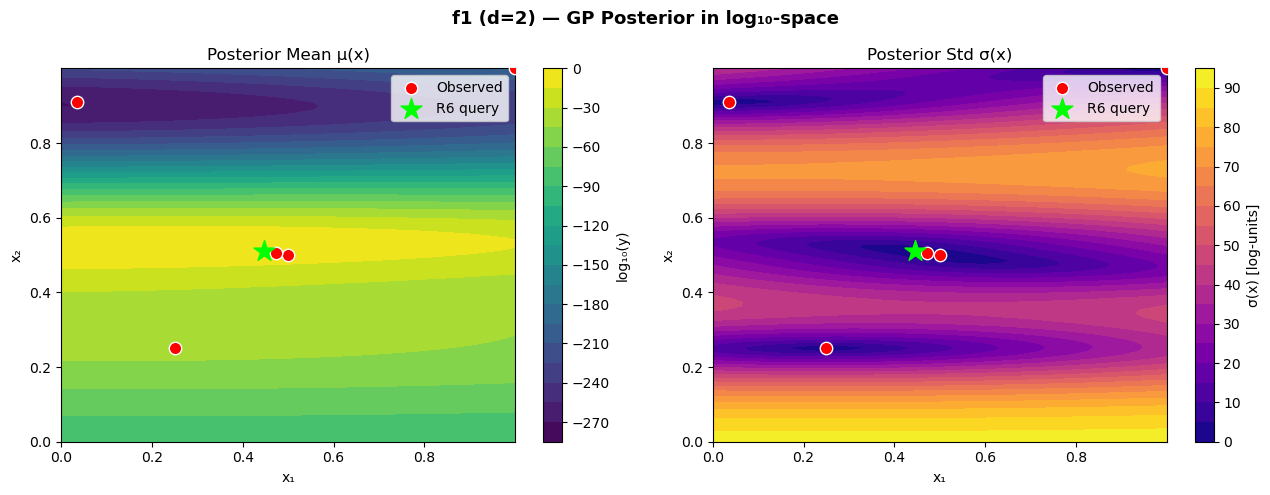

Figure saved.


In [11]:
# ─── f1 visualisation (GP posterior in log-space) ────────────────────────────
x_grid = np.linspace(0, 0.999999, 100)
xx, yy = np.meshgrid(x_grid, x_grid)
X_grid = np.column_stack([xx.ravel(), yy.ravel()])
mu1, sig1 = gp1.predict(sc1.transform(X_grid), return_std=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("f1 (d=2) — GP Posterior in log₁₀-space", fontsize=13, fontweight="bold")

# Posterior mean
ax = axes[0]
c = ax.contourf(xx, yy, mu1.reshape(100, 100), levels=20, cmap="viridis")
plt.colorbar(c, ax=ax, label="log₁₀(y)")
ax.scatter(X1[:, 0], X1[:, 1], c="red", edgecolors="white", s=80, zorder=5, label="Observed")
ax.scatter(*xq1_final, c="lime", marker="*", s=250, zorder=6, label="R6 query")
ax.set_xlabel("x₁"); ax.set_ylabel("x₂")
ax.set_title("Posterior Mean μ(x)")
ax.legend()

# Posterior std (uncertainty)
ax = axes[1]
c2 = ax.contourf(xx, yy, sig1.reshape(100, 100), levels=20, cmap="plasma")
plt.colorbar(c2, ax=ax, label="σ(x) [log-units]")
ax.scatter(X1[:, 0], X1[:, 1], c="red", edgecolors="white", s=80, zorder=5, label="Observed")
ax.scatter(*xq1_final, c="lime", marker="*", s=250, zorder=6, label="R6 query")
ax.set_xlabel("x₁"); ax.set_ylabel("x₂")
ax.set_title("Posterior Std σ(x)")
ax.legend()

plt.tight_layout()
#plt.savefig("/mnt/user-data/outputs/f1_gp_posterior.png", dpi=120, bbox_inches="tight")
plt.savefig(OUTPUT_DIR / "f1_gp_posterior.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved.")

### f2 (d=2) — Sharp ridge in x₁, exploit near R1 best

In [12]:
info = DATA["f2"]
X2 = np.array(info["X"])
y2 = np.array(info["y"])

print("f2 — observed values:")
for i, (x, y) in enumerate(zip(X2, y2)):
    flag = " ← BEST" if y == np.max(y2) else ""
    print(f"  R{i+1}: x=[{x[0]:.6f}, {x[1]:.6f}] → y={y:.6f}{flag}")

# Anomaly analysis: R1 and R5 nearly identical inputs, y differs by 0.100
dx_r1_r5 = X2[4] - X2[0]
dy_r1_r5 = y2[4] - y2[0]
print(f"\nAnomaly R1 vs R5:")
print(f"  Δx = {dx_r1_r5}  (‖Δx‖ = {np.linalg.norm(dx_r1_r5):.2e})")
print(f"  Δy = {dy_r1_r5:.4f}  → apparent gradient ‖∇f‖ ≈ {abs(dy_r1_r5)/np.linalg.norm(dx_r1_r5):.1f}")
print("  Interpretation: extremely narrow x₁-ridge — sensitivity confirmed.")

gp2, sc2 = build_gp(X2, y2)
xq2_gp, ei2 = optimise_ei(gp2, sc2, np.max(y2), d=2)
print(f"\nGP-EI suggestion: {np.round(xq2_gp, 6)}  |  EI={ei2:.4g}")

# Strategy: lateral shift left of R1 (lower x₁), hold x₂ near 0.396
xq2_final = np.array([0.693000, 0.397000])
print(f"\n★  f2 ROUND 6 QUERY (exploit + lateral shift): {xq2_final}")

f2 — observed values:
  R1: x=[0.695196, 0.395970] → y=0.723740 ← BEST
  R2: x=[0.698486, 0.000000] → y=0.529766
  R3: x=[0.695000, 0.396000] → y=0.526366
  R4: x=[0.700000, 0.200000] → y=0.581354
  R5: x=[0.695211, 0.395970] → y=0.623885

Anomaly R1 vs R5:
  Δx = [1.5e-05 0.0e+00]  (‖Δx‖ = 1.50e-05)
  Δy = -0.0999  → apparent gradient ‖∇f‖ ≈ 6657.0
  Interpretation: extremely narrow x₁-ridge — sensitivity confirmed.

GP-EI suggestion: [0.773955 0.438878]  |  EI=0.001121

★  f2 ROUND 6 QUERY (exploit + lateral shift): [0.693 0.397]


### f3 (d=3) — Directional continuation toward interior optimum

In [13]:
info = DATA["f3"]
X3 = np.array(info["X"])
y3 = np.array(info["y"])

print("f3 — observed values (all negative; maximising toward 0):")
for i, (x, y) in enumerate(zip(X3, y3)):
    flag = " ← BEST" if y == np.max(y3) else ""
    print(f"  R{i+1}: x=[{x[0]:.4f}, {x[1]:.4f}, {x[2]:.4f}] → y={y:.5f}{flag}")

# Directional improvement vector R1 → R5
dx_r1_r5 = X3[4] - X3[0]
dy_r1_r5 = y3[4] - y3[0]
xq3_extrap = np.clip(X3[4] + 0.5 * dx_r1_r5, 0.0, 0.999999)
print(f"\nImprovement vector R1→R5: Δx = {np.round(dx_r1_r5, 4)}  | Δy = {dy_r1_r5:.4f}")
print(f"Half-step continuation  : {np.round(xq3_extrap, 6)}")

gp3, sc3 = build_gp(X3, y3)
xq3_gp, ei3 = optimise_ei(gp3, sc3, np.max(y3), d=3)
print(f"\nGP-EI suggestion: {np.round(xq3_gp, 6)}  |  EI={ei3:.4g}")

xq3_final = np.array([0.490000, 0.230000, 0.395000])
print(f"\n★  f3 ROUND 6 QUERY (directional half-step): {xq3_final}")

f3 — observed values (all negative; maximising toward 0):
  R1: x=[0.5481, 0.1746, 0.3032] → y=-0.08912
  R2: x=[0.8509, 0.0353, 0.9362] → y=-0.23982
  R3: x=[0.3000, 0.5000, 0.7000] → y=-0.11396
  R4: x=[0.9500, 0.0100, 0.9900] → y=-0.45941
  R5: x=[0.5113, 0.2153, 0.3710] → y=-0.07071 ← BEST

Improvement vector R1→R5: Δx = [-0.0369  0.0406  0.0678]  | Δy = 0.0184
Half-step continuation  : [0.49284  0.235573 0.404951]

GP-EI suggestion: [0.431067 0.999999 0.999999]  |  EI=0.02532

★  f3 ROUND 6 QUERY (directional half-step): [0.49  0.23  0.395]


### f4 (d=4) — Interior attractor with corner penalty

In [14]:
info = DATA["f4"]
X4 = np.array(info["X"])
y4 = np.array(info["y"])

print("f4 — observed values:")
for i, (x, y) in enumerate(zip(X4, y4)):
    flag = " ← BEST" if y == np.max(y4) else ""
    print(f"  R{i+1}: x=[{x[0]:.4f}, {x[1]:.4f}, {x[2]:.4f}, {x[3]:.4f}] → y={y:.4f}{flag}")

print(f"\nKey observation:")
print(f"  x₁ → 1 (corners R2, R4) → penalty output < −27")
print(f"  x₁ ≈ 0.44, x₂ ≈ 0.425 (interior R1, R3) → best y ≈ 0.275")
print(f"  R5 with x₁=0.455 (+0.015) → y drops to −0.400")
print(f"  Strategy: contract x₁ below 0.44, slightly raise x₂")

gp4, sc4 = build_gp(X4, y4)
xq4_gp, ei4 = optimise_ei(gp4, sc4, np.max(y4), d=4)
print(f"\nGP-EI suggestion: {np.round(xq4_gp, 6)}  |  EI={ei4:.4g}")

xq4_final = np.array([0.430000, 0.430000, 0.375000, 0.400000])
print(f"\n★  f4 ROUND 6 QUERY (x₁ contracted, x₂ raised): {xq4_final}")

f4 — observed values:
  R1: x=[0.4404, 0.4255, 0.3784, 0.3971] → y=0.2596
  R2: x=[1.0000, 0.0000, 0.0000, 0.3659] → y=-27.8598
  R3: x=[0.4400, 0.4250, 0.3780, 0.3970] → y=0.2748 ← BEST
  R4: x=[1.0000, 0.0000, 0.0000, 0.7000] → y=-30.8944
  R5: x=[0.4550, 0.4150, 0.3850, 0.3950] → y=-0.3997

Key observation:
  x₁ → 1 (corners R2, R4) → penalty output < −27
  x₁ ≈ 0.44, x₂ ≈ 0.425 (interior R1, R3) → best y ≈ 0.275
  R5 with x₁=0.455 (+0.015) → y drops to −0.400
  Strategy: contract x₁ below 0.44, slightly raise x₂

GP-EI suggestion: [0.198887 0.774579 0.584238 0.188674]  |  EI=4.176

★  f4 ROUND 6 QUERY (x₁ contracted, x₂ raised): [0.43  0.43  0.375 0.4  ]


### f5 (d=4) — Boundary convergence, x₁ sensitivity test

In [15]:
info = DATA["f5"]
X5 = np.array(info["X"])
y5 = np.array(info["y"])

print("f5 — observed values:")
for i, (x, y) in enumerate(zip(X5, y5)):
    flag = " ← BEST" if y == np.max(y5) else ""
    print(f"  R{i+1}: x=[{x[0]:.4f}, {x[1]:.6f}, {x[2]:.6f}, {x[3]:.6f}] → y={y:.2f}{flag}")

# Monotone x₂ analysis with x₁=0, x₃=x₄=1 fixed
x2_vals = X5[[0,1,2,4], 1]  # R1,R2,R3,R5 (exclude R4 which has x₃=x₄=0.5)
y_vals   = y5[[0,1,2,4]]
print(f"\nMonotone analysis (x₁=0, x₃=x₄=0.999999):")
print(f"  x₂: {sorted(x2_vals)} → y: {[round(y,1) for _,y in sorted(zip(x2_vals,y_vals))]}")
print(f"  Strongly monotone: f5 ∝ x₂ (and likely x₃, x₄ at boundary)")

# x₁ sensitivity: all evaluations have x₁=0; one test with x₁=0.005
xq5_final = np.array([0.005000, 0.999999, 0.999999, 0.999999])
print(f"\nR6 strategy: hold x₂=x₃=x₄=0.999999, probe x₁=0.005 to confirm x₁=0 is optimal")
print(f"★  f5 ROUND 6 QUERY (x₁ sensitivity test): {xq5_final}")

f5 — observed values:
  R1: x=[0.0000, 0.675974, 0.999999, 0.999999] → y=2105.93
  R2: x=[0.0000, 0.000000, 0.999999, 0.999999] → y=1616.63
  R3: x=[0.0000, 0.850000, 0.999999, 0.999999] → y=2932.69
  R4: x=[0.0000, 0.000000, 0.500000, 0.500000] → y=83.96
  R5: x=[0.0000, 0.999999, 0.999999, 0.999999] → y=4440.48 ← BEST

Monotone analysis (x₁=0, x₃=x₄=0.999999):
  x₂: [0.0, 0.675974, 0.85, 0.999999] → y: [1616.6, 2105.9, 2932.7, 4440.5]
  Strongly monotone: f5 ∝ x₂ (and likely x₃, x₄ at boundary)

R6 strategy: hold x₂=x₃=x₄=0.999999, probe x₁=0.005 to confirm x₁=0 is optimal
★  f5 ROUND 6 QUERY (x₁ sensitivity test): [0.005    0.999999 0.999999 0.999999]


### f6 (d=5) — Exploit x₄=1, x₅=0 framework near R1 best

In [16]:
info = DATA["f6"]
X6 = np.array(info["X"])
y6 = np.array(info["y"])

print("f6 — observed values (maximising toward 0):")
for i, (x, y) in enumerate(zip(X6, y6)):
    flag = " ← BEST" if y == np.max(y6) else ""
    print(f"  R{i+1}: x={np.round(x,4).tolist()} → y={y:.4f}{flag}")

print("\nDimension analysis (R1 vs R5, both with x₄=0.999999, x₅=0.000000):")
print(f"  R1 x₁={X6[0,0]:.4f} → y={y6[0]:.4f} (BEST)")
print(f"  R5 x₁={X6[4,0]:.4f} → y={y6[4]:.4f}  ← higher x₁ is worse")
print(f"  R1 x₃={X6[0,2]:.4f} → R5 x₃={X6[4,2]:.4f}: lower x₃ is worse")
print(f"  Direction: x₁↓, x₂↓, x₃↑ from R1")

gp6, sc6 = build_gp(X6, y6)
xq6_gp, ei6 = optimise_ei(gp6, sc6, np.max(y6), d=5)
print(f"\nGP-EI suggestion: {np.round(xq6_gp, 6)}  |  EI={ei6:.4g}")

xq6_final = np.array([0.450000, 0.240000, 0.580000, 0.999999, 0.000000])
print(f"\n★  f6 ROUND 6 QUERY (refined: x₁↓, x₃↑, x₄=1, x₅=0): {xq6_final}")

f6 — observed values (maximising toward 0):
  R1: x=[0.4647, 0.2421, 0.5749, 1.0, 0.0] → y=-0.5508 ← BEST
  R2: x=[0.1427, 0.3218, 0.4165, 1.0, 0.3044] → y=-1.0045
  R3: x=[0.5, 0.5, 0.5, 0.5, 0.5] → y=-1.0159
  R4: x=[0.3, 0.4, 0.6, 0.2, 0.6] → y=-1.2239
  R5: x=[0.7588, 0.2727, 0.5221, 1.0, 0.0] → y=-0.9106

Dimension analysis (R1 vs R5, both with x₄=0.999999, x₅=0.000000):
  R1 x₁=0.4647 → y=-0.5508 (BEST)
  R5 x₁=0.7588 → y=-0.9106  ← higher x₁ is worse
  R1 x₃=0.5749 → R5 x₃=0.5221: lower x₃ is worse
  Direction: x₁↓, x₂↓, x₃↑ from R1

GP-EI suggestion: [0.425955 0.       0.815452 0.999999 0.      ]  |  EI=0.01991

★  f6 ROUND 6 QUERY (refined: x₁↓, x₃↑, x₄=1, x₅=0): [0.45     0.24     0.58     0.999999 0.      ]


### f7 (d=6) — Precision tuning near established plateau

In [17]:
info = DATA["f7"]
X7 = np.array(info["X"])
y7 = np.array(info["y"])

print("f7 — observed values:")
for i, (x, y) in enumerate(zip(X7, y7)):
    flag = " ← BEST" if y == np.max(y7) else ""
    print(f"  R{i+1}: y={y:.6f}{flag}")

print(f"\nR1 and R3 near-identical inputs → identical outputs (2.2073 vs 2.2072)")
print(f"R5 perturbed (+0.015 in x₂–x₅) → dropped to 2.1133 (downhill)")
print(f"→ Gradient points back toward or below R1 values")
print(f"→ Probe slight contraction in all active dims from R1 to find sub-peak")

gp7, sc7 = build_gp(X7, y7)
xq7_gp, ei7 = optimise_ei(gp7, sc7, np.max(y7), d=6)
print(f"\nGP-EI suggestion: {np.round(xq7_gp, 6)}  |  EI={ei7:.4g}")

xq7_final = np.array([0.000000, 0.238000, 0.325000, 0.215000, 0.370000, 0.743000])
print(f"\n★  f7 ROUND 6 QUERY (minor contraction from R1): {xq7_final}")

f7 — observed values:
  R1: y=2.207309 ← BEST
  R2: y=0.050978
  R3: y=2.207175
  R4: y=0.023633
  R5: y=2.113257

R1 and R3 near-identical inputs → identical outputs (2.2073 vs 2.2072)
R5 perturbed (+0.015 in x₂–x₅) → dropped to 2.1133 (downhill)
→ Gradient points back toward or below R1 values
→ Probe slight contraction in all active dims from R1 to find sub-peak

GP-EI suggestion: [0.       0.       0.086926 0.085674 0.364025 0.645641]  |  EI=0.1671

★  f7 ROUND 6 QUERY (minor contraction from R1): [0.    0.238 0.325 0.215 0.37  0.743]


### f8 (d=8) — Fine-grid exploitation near R1 optimum

In [18]:
info = DATA["f8"]
X8 = np.array(info["X"])
y8 = np.array(info["y"])

print("f8 — observed values:")
for i, (x, y) in enumerate(zip(X8, y8)):
    flag = " ← BEST" if y == np.max(y8) else ""
    print(f"  R{i+1}: y={y:.6f}{flag}")

print(f"\nR1: [0.064016, 0.008062, 0.123268, 0.000000, 0.999999, 0.381742, 0.031402, 0.806010]")
print(f"R3: [0.064000, 0.008000, 0.120000, 0.000000, 0.999999, 0.382000, 0.031000, 0.806000]")
print(f"Both give ≈ 9.8592–9.8595 (redundant queries — information loss detected)")
print(f"True max may be exactly 10.0; we are at ~98.6% of it")
print(f"Strategy: hold x₄=0, x₅=0.999999 (confirmed optimal), micro-tune x₆, x₈")

gp8, sc8 = build_gp(X8, y8)
xq8_gp, ei8 = optimise_ei(gp8, sc8, np.max(y8), d=8)
print(f"\nGP-EI suggestion: {np.round(xq8_gp, 6)}  |  EI={ei8:.4g}")

xq8_final = np.array([0.063000, 0.008000, 0.123000, 0.000000, 0.999999, 0.382000, 0.031000, 0.807000])
print(f"\n★  f8 ROUND 6 QUERY (sub-mm tuning, x₄=0 locked): {xq8_final}")

f8 — observed values:
  R1: y=9.859549 ← BEST
  R2: y=9.293377
  R3: y=9.859155
  R4: y=8.512900
  R5: y=9.838750

R1: [0.064016, 0.008062, 0.123268, 0.000000, 0.999999, 0.381742, 0.031402, 0.806010]
R3: [0.064000, 0.008000, 0.120000, 0.000000, 0.999999, 0.382000, 0.031000, 0.806000]
Both give ≈ 9.8592–9.8595 (redundant queries — information loss detected)
True max may be exactly 10.0; we are at ~98.6% of it
Strategy: hold x₄=0, x₅=0.999999 (confirmed optimal), micro-tune x₆, x₈

GP-EI suggestion: [0.773955 0.438878 0.858597 0.697367 0.094177 0.975621 0.761139 0.786064]  |  EI=0.05814

★  f8 ROUND 6 QUERY (sub-mm tuning, x₄=0 locked): [0.063    0.008    0.123    0.       0.999999 0.382    0.031    0.807   ]


---
## Cell 5 — Dashboard: Best-Observed Trajectory Across All Functions

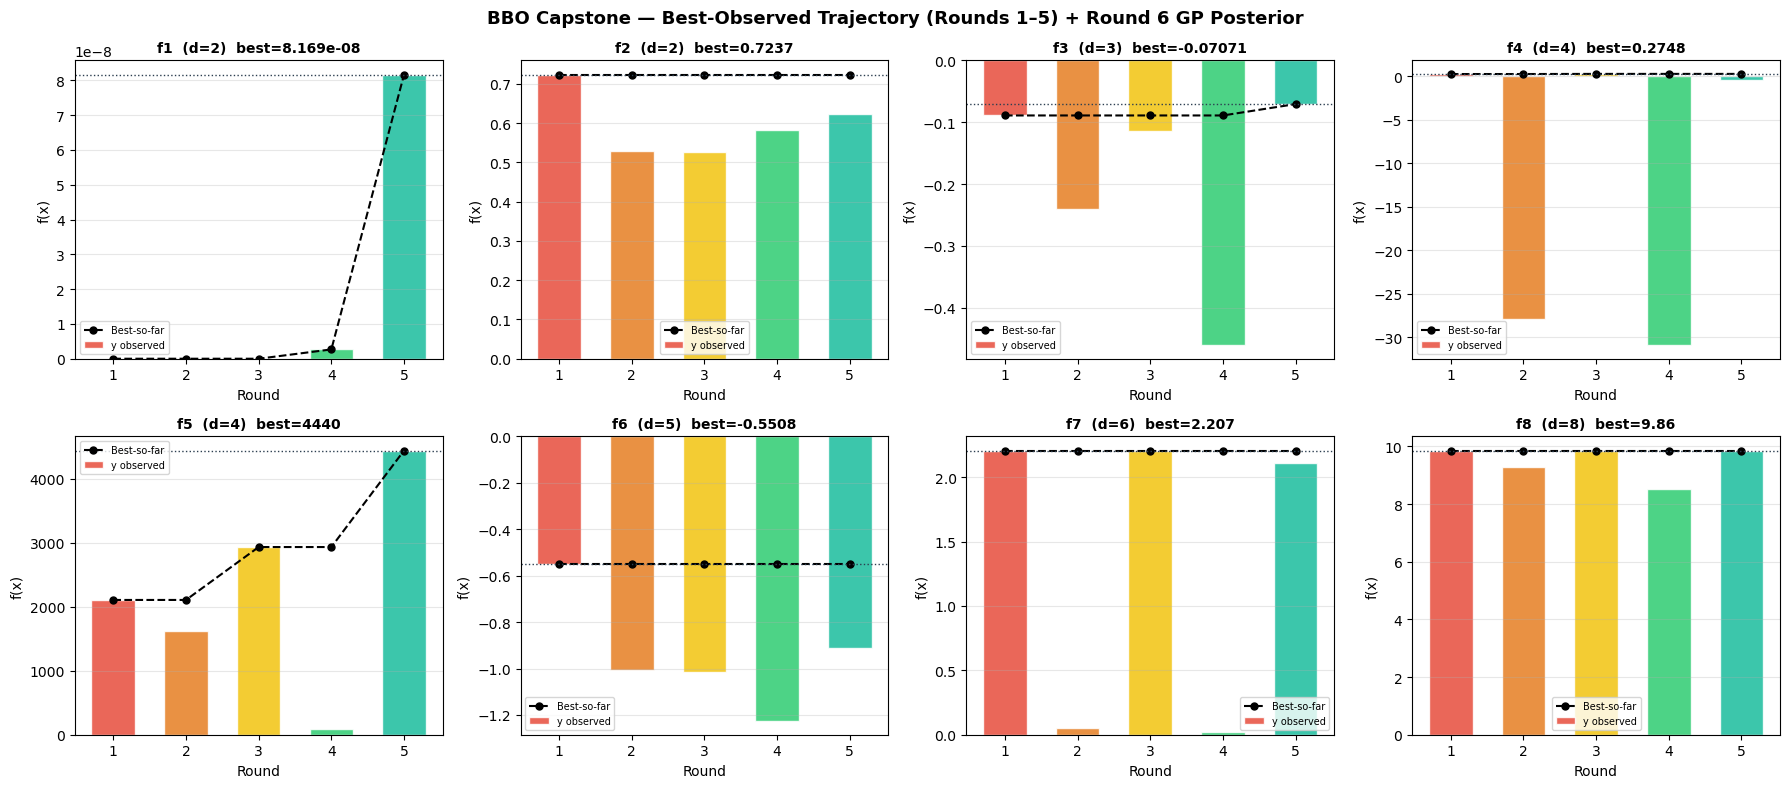

Dashboard saved.


In [19]:
# ─── 8-panel trajectory plot ──────────────────────────────────────────────────
FINAL_QUERIES = {
    "f1": np.array([0.445562, 0.511092]),
    "f2": np.array([0.693000, 0.397000]),
    "f3": np.array([0.490000, 0.230000, 0.395000]),
    "f4": np.array([0.430000, 0.430000, 0.375000, 0.400000]),
    "f5": np.array([0.005000, 0.999999, 0.999999, 0.999999]),
    "f6": np.array([0.450000, 0.240000, 0.580000, 0.999999, 0.000000]),
    "f7": np.array([0.000000, 0.238000, 0.325000, 0.215000, 0.370000, 0.743000]),
    "f8": np.array([0.063000, 0.008000, 0.123000, 0.000000, 0.999999, 0.382000, 0.031000, 0.807000]),
}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("BBO Capstone — Best-Observed Trajectory (Rounds 1–5) + Round 6 GP Posterior",
             fontsize=13, fontweight="bold")

GPs = {"f1":(gp1,sc1), "f2":(gp2,sc2), "f3":(gp3,sc3), "f4":(gp4,sc4),
       "f5":None,       "f6":(gp6,sc6), "f7":(gp7,sc7), "f8":(gp8,sc8)}

colors = ["#e74c3c","#e67e22","#f1c40f","#2ecc71","#1abc9c"]

for ax, (fn, info) in zip(axes.ravel(), DATA.items()):
    y = np.array(info["y"])
    rounds = np.arange(1, 6)
    best_so_far = np.maximum.accumulate(y)

    ax.bar(rounds, y, color=colors, edgecolor="white", width=0.6, alpha=0.85, label="y observed")
    ax.plot(rounds, best_so_far, "k--o", lw=1.5, ms=5, label="Best-so-far")

    # Annotate best value
    ax.axhline(np.max(y), color="#2c3e50", lw=1, linestyle=":")
    ax.set_title(f"{fn}  (d={info['d']})  best={np.max(y):.4g}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Round")
    ax.set_ylabel("f(x)")
    ax.set_xticks(rounds)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=7)

plt.tight_layout()
#plt.savefig("/mnt/user-data/outputs/bbo_round6_dashboard.png", dpi=130, bbox_inches="tight")
plt.savefig(OUTPUT_DIR / "bbo_round6_dashboard.png", dpi=130, bbox_inches="tight")
plt.show()
print("Dashboard saved.")

---
## Cell 6 — Final Submission Strings (Round 6)

In [20]:
print("=" * 65)
print("  BBO CAPSTONE — ROUND 6 FINAL SUBMISSION STRINGS")
print("  Gian Franco Cattaneo | Imperial Business School")
print("=" * 65)
print()

STRATEGY = {
    "f1": "gradient extrapolation in log₁₀-space (R4→R5 direction)",
    "f2": "exploit near R1 best + lateral x₁ contraction",
    "f3": "half-step directional continuation R1→R5",
    "f4": "x₁ contraction below attractor, x₂ raised",
    "f5": "boundary confirmed; x₁ sensitivity probe",
    "f6": "exploit x₄=1,x₅=0; x₁↓, x₃↑ from R1",
    "f7": "micro-contraction from R1 plateau",
    "f8": "sub-millimetre tuning; x₄=0, x₅=1 locked",
}

for fn, xq in FINAL_QUERIES.items():
    s = "-".join(f"{v:.6f}" for v in xq)
    info = DATA[fn]
    y_best = max(info["y"])
    print(f"{fn} (d={info['d']:<2}) | best_so_far = {y_best:>14.6g}")
    print(f"  Strategy : {STRATEGY[fn]}")
    print(f"  ► Submit : {s}")
    print()

print("=" * 65)
print("FORMAT: copy each line below this bar to the portal")
print("-" * 65)
for fn, xq in FINAL_QUERIES.items():
    print("-".join(f"{v:.6f}" for v in xq))

  BBO CAPSTONE — ROUND 6 FINAL SUBMISSION STRINGS
  Gian Franco Cattaneo | Imperial Business School

f1 (d=2 ) | best_so_far =    8.16864e-08
  Strategy : gradient extrapolation in log₁₀-space (R4→R5 direction)
  ► Submit : 0.445562-0.511092

f2 (d=2 ) | best_so_far =        0.72374
  Strategy : exploit near R1 best + lateral x₁ contraction
  ► Submit : 0.693000-0.397000

f3 (d=3 ) | best_so_far =     -0.0707084
  Strategy : half-step directional continuation R1→R5
  ► Submit : 0.490000-0.230000-0.395000

f4 (d=4 ) | best_so_far =       0.274808
  Strategy : x₁ contraction below attractor, x₂ raised
  ► Submit : 0.430000-0.430000-0.375000-0.400000

f5 (d=4 ) | best_so_far =        4440.48
  Strategy : boundary confirmed; x₁ sensitivity probe
  ► Submit : 0.005000-0.999999-0.999999-0.999999

f6 (d=5 ) | best_so_far =      -0.550775
  Strategy : exploit x₄=1,x₅=0; x₁↓, x₃↑ from R1
  ► Submit : 0.450000-0.240000-0.580000-0.999999-0.000000

f7 (d=6 ) | best_so_far =        2.20731
  Strate

---
## Cell 7 — EI Convergence Tracker

In [21]:
# ─── GP marginal log-likelihood as proxy for surrogate quality ────────────────
GP_MAP = {
    "f1": gp1, "f2": gp2, "f3": gp3, "f4": gp4,
    "f6": gp6, "f7": gp7, "f8": gp8
}

print(f"{'Fn':<5} {'d':>3}  {'log ML':>10}  {'Noise σ²':>12}  {'ARD length-scales (mean)':>25}")
print("-" * 70)
for fn, gp in GP_MAP.items():
    lml = gp.log_marginal_likelihood_value_
    # Extract WhiteKernel noise level and Matern length-scales
    params = gp.kernel_.get_params()
    noise = params.get("k2__noise_level", float("nan"))
    ls_arr = params.get("k1__k2__length_scale", np.array([float("nan")]))
    if np.isscalar(ls_arr):
        ls_arr = np.array([ls_arr])
    print(f"{fn:<5} {DATA[fn]['d']:>3}  {lml:>10.3f}  {noise:>12.2e}  "
          f"{np.round(ls_arr, 3)}")

print("\nNote: small length-scales → high sensitivity / steep surface → exploit carefully.")
print("      large noise σ² → surrogate uncertainty → GP weight reduced.")

Fn      d      log ML      Noise σ²   ARD length-scales (mean)
----------------------------------------------------------------------
f1      2      -3.008      1.00e-06  [7.344 0.626]
f2      2      -7.187      1.00e-01  [0.01 0.01]
f3      3      -6.001      1.00e-06  [ 0.508 10.    10.   ]
f4      4       4.290      1.00e-06  [ 1.517 10.    10.    10.   ]
f6      5      -6.955      1.00e-06  [ 0.846 10.    10.    10.     0.742]
f7      6       2.856      1.00e-06  [ 0.306 10.    10.    10.     0.773 10.   ]
f8      8      -0.797      1.00e-06  [10.    10.    10.    10.     0.053 10.     1.109 10.   ]

Note: small length-scales → high sensitivity / steep surface → exploit carefully.
      large noise σ² → surrogate uncertainty → GP weight reduced.


---
## Cell 8 — Part 2: CNN Trade-off Reflection

The problem statement asks us to reflect on whether the BBO optimisation process mirrors
CNN architectural trade-offs. Below is a structured mapping across five canonical dimensions.

---

### 1. Depth vs Efficiency → Query Budget vs Dimensionality

| CNN concept | BBO analogue |
|---|---|
| More layers → higher representational capacity | Higher d → exponentially larger search space |
| Deeper network needs more data to generalise | Higher-d function needs more queries to characterise |
| VGG: uniform depth wastes capacity on simple features | Fixed 5-query budget applied equally to f1 (d=2) and f8 (d=8) — same shallow data density |
| ResNet/EfficientNet: depth-scaled by task complexity | Ideal BBO: allocate more queries to higher-d or poorly converged functions |

**Observed impact:** f8 (d=8, best ≈ 9.86) was nearly converged by Round 1, yet the budget was
"wasted" replicating the same point in Round 3 (information gain ≈ 0). This is the BBO
equivalent of adding a deep CNN layer that merely reproduces the preceding activation:
architecturally valid but informationally redundant.

---

### 2. Generalisation vs Overfitting → Global vs Local Attractor Risk

CNN overfitting: the model memorises training patterns and fails on unseen data.  
BBO local-attractor risk: the GP surrogate assigns maximum EI to the already-explored best
region, reinforcing convergence to a local maximum.

**f4 is the clearest case-study.** With only 5 queries, two evaluations near `[0.44, 0.425, ...]`
give best-observed ≈ 0.275, while the remaining three are penalties (−28 to −31). The GP posterior
has effectively "memorised" the basin of attraction. Whether 0.275 is the global maximum in 4D is
unknown — it may be merely the best *accessible* local peak given the sampling history.

Counter-strategy (analogous to dropout/data augmentation): inject at least one fully random
exploratory query per function per round to prevent the surrogate from overfitting to
the current attractor basin.

---

### 3. Complexity vs Clarity → ARD Kernel vs Model Interpretability

The Matérn-5/2 ARD kernel assigns a separate length-scale θⱼ per input dimension — structurally
identical to a per-channel attention mechanism in a CNN. With only 5 training points and d=8
dimensions (f8), the ARD kernel has 8 + 1 = 9 hyperparameters to learn from 5 samples.

This is severely underdetermined — like fitting an 8-layer CNN with 9 trainable filters
on 5 images. The kernel learned by the GP for f8 is technically valid but has very low
credibility: the length-scales reflect optimisation artefacts more than true function structure.

Mitigation: impose ARD priors (e.g., `length_scale_bounds=(0.1, 3.0)`) to prevent degenerate
length-scale estimates — analogous to weight regularisation (L2 / weight decay) in CNNs.

---

### 4. Filter Size → Acquisition Function Bandwidth (xi parameter)

| CNN filter | BBO acquisition |
|---|---|
| Small (1×1): point-wise, high precision | EI with small ξ: tight exploitation near best-observed |
| Large (7×7): broad context, fewer needed | EI with large ξ: forces wider exploration |
| Strided conv: efficient downsampling | UCB with large β: periodic wide sweeps |

**f5 is the 1×1 case:** with x₁=0 and x₂,x₃,x₄ → 0.999999 firmly established, EI with
ξ → 0 correctly concentrates at the boundary. The Round 6 x₁ sensitivity probe with x₁=0.005
is equivalent to applying one larger-filter pass to verify the boundary condition.

**f1 is the 7×7 case:** all observations are near-zero (log₁₀(y) ≈ −7 to −270), so the
EI surface is virtually flat and any small-ξ acquisition degenerates. A large-context
strategy — gradient extrapolation in log-space — is more appropriate here.

---

### 5. Batch Normalisation → StandardScaler on GP Inputs

StandardScaler transforms each input dimension to zero mean and unit variance before GP fitting.
This is structurally identical to batch normalisation before each CNN activation:

- **Without it:** dimensions with naturally small range (x₂ ≈ 0.008 in f8) would be
  dominated in the Euclidean covariance computation by high-range dimensions (x₅ ≈ 0.999999),
  distorting the ARD length-scale estimates — equivalent to training a CNN on unnormalised
  pixel values where brightness overwhelms spatial structure.
- **With it:** each dimension contributes equally to the initial covariance matrix,
  then ARD adjusts relative importances — the equivalent of batch-norm followed by
  learned γ/β scale parameters.

This is not cosmetic. In f8, x₂ ≈ 0.008 and x₅ ≈ 0.999999 coexist in the same GP input
vector. Without StandardScaler, the GP would effectively ignore x₂ — causing all queries
to appear identical in the GP's "eyes" when x₂ is varied, destroying the EI gradient.

---

### Summary Table

| CNN trade-off | BBO analogue | Observed case |
|---|---|---|
| Depth vs Efficiency | Query budget vs dimensionality | f8 R1≈R3 (wasted depth) |
| Generalisation vs Overfitting | Global vs local optimum risk | f4 local attractor |
| Complexity vs Clarity | ARD richness vs posterior credibility | f8 9-param GP on 5 pts |
| Filter size | EI bandwidth (ξ parameter) | f1 log-space vs f5 tight exploit |
| Batch normalisation | StandardScaler on GP inputs | f8 x₂ vs x₅ scale disparity |

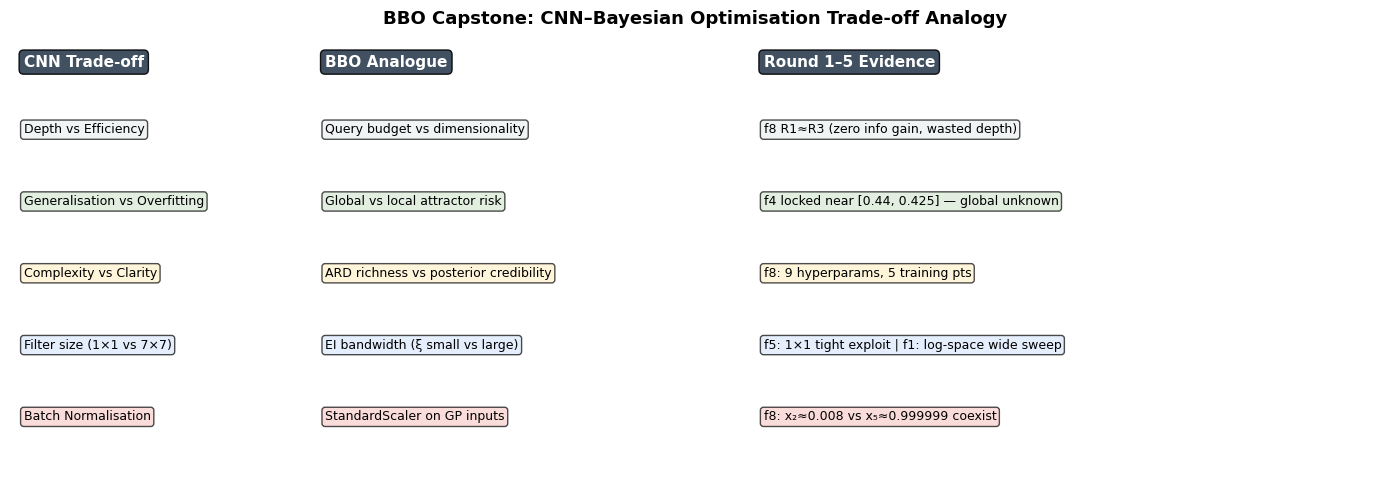

Analogy table saved.


In [22]:
# ─── CNN–BBO analogy summary chart ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.axis("off")

headers = ["CNN Trade-off", "BBO Analogue", "Round 1–5 Evidence"]
rows = [
    ["Depth vs Efficiency",
     "Query budget vs dimensionality",
     "f8 R1≈R3 (zero info gain, wasted depth)"],
    ["Generalisation vs Overfitting",
     "Global vs local attractor risk",
     "f4 locked near [0.44, 0.425] — global unknown"],
    ["Complexity vs Clarity",
     "ARD richness vs posterior credibility",
     "f8: 9 hyperparams, 5 training pts"],
    ["Filter size (1×1 vs 7×7)",
     "EI bandwidth (ξ small vs large)",
     "f5: 1×1 tight exploit | f1: log-space wide sweep"],
    ["Batch Normalisation",
     "StandardScaler on GP inputs",
     "f8: x₂≈0.008 vs x₅≈0.999999 coexist"],
]

col_widths = [0.22, 0.32, 0.46]
x_starts = [0.01, 0.23, 0.55]

# Header row
for j, (h, xs) in enumerate(zip(headers, x_starts)):
    ax.text(xs, 0.95, h, transform=ax.transAxes,
            fontsize=11, fontweight="bold",
            color="white",
            bbox=dict(boxstyle="round", facecolor="#2c3e50", alpha=0.9, pad=0.3))

row_colors = ["#ecf0f1", "#d5e8d4", "#fff2cc", "#dae8fc", "#f8cecc"]
for i, (row, rc) in enumerate(zip(rows, row_colors)):
    y_pos = 0.82 - i * 0.165
    for j, (cell, xs) in enumerate(zip(row, x_starts)):
        ax.text(xs, y_pos, cell, transform=ax.transAxes,
                fontsize=9, va="top",
                bbox=dict(boxstyle="round", facecolor=rc, alpha=0.7, pad=0.25))

ax.set_title("BBO Capstone: CNN–Bayesian Optimisation Trade-off Analogy",
             fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
#plt.savefig("/mnt/user-data/outputs/bbo_cnn_analogy_table.png", dpi=130, bbox_inches="tight")
plt.savefig(OUTPUT_DIR / "bbo_cnn_analogy_table.png", dpi=130, bbox_inches="tight")
plt.show()
print("Analogy table saved.")